In [28]:
# importing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [29]:
df = pd.read_csv("advertising.csv")

In [30]:
print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [31]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None


In [32]:
print(df.describe())

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


### Insight
Dataset contains 200 observations.
No categorical variables.
Sales is the target variable.

In [33]:
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


### Insight
No missing values.
No cleaning required.

In [34]:
# Correlation Analysis
print(df.corr())

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


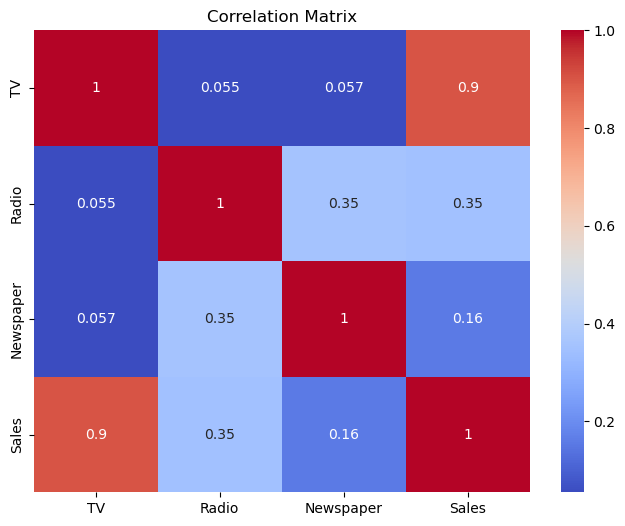

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

###  Insights
- TV advertising shows a very strong positive relationship with Sales (0.901).
- Radio advertising has a moderate positive relationship with Sales (0.350).
- Newspaper advertising has a weak relationship with Sales (0.158).

#### Business Insight
 TV appears to be the most effective advertising channel for increasing sales.

In [18]:
# Define Features
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

In [19]:
# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Train MLR Model
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [21]:
# Coefficients
print("Intercept:",model.intercept_)
coef_df = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})
print(coef_df)

Intercept: 4.714126402214134
     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337


#### Insights
 -- Model Equation
Sales=4.714+0.0545(TV)+0.1009(Radio)+0.0043(Newspaper)

-- Interpretation

- TV
Coefficient = 0.0545
Keeping all other variables constant:Every additional 1 unit spent on TV advertising increases expected sales by 
approximately 0.0545 units.

- Radio
Coefficient = 0.1009
Every additional 1 unit spent on Radio advertising increases expected sales by approximately 0.1009 units.

- Newspaper
Coefficient = 0.0043
Newspaper advertising has almost no impact on sales.

In [23]:
# Predictions
y_pred = model.predict(X_test)

print(y_pred[:10])

[17.0347724  20.40974033 23.72398873  9.27278518 21.68271879 12.56940161
 21.08119452  8.69035045 17.23701254 16.66657475]


### Insights
predicted sales values generated by the model using advertising spending information.
The model is estimating future sales based on marketing investments.

In [24]:
# Model Evaluation
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np

r2 = r2_score(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test,y_pred)
print("R2:",r2)
print("MSE:",mse)
print("RMSE:",rmse)
print("MAE:",mae)


R2: 0.9059011844150826
MSE: 2.9077569102710923
RMSE: 1.7052146229349232
MAE: 1.2748262109549344


### Insights
R² = 0.906, Approximately 90.6% of the variation in Sales is explained by TV, Radio, and Newspaper advertising.
This is an excellent result.

MAE = 1.27
Predictions differ from actual sales by about 1.27 units on average.

RMSE = 1.71
The model has relatively low prediction error, indicating good predictive performance.

In [25]:
# Adjusted R² + P-value + T-value
import statsmodels.api as sm

X_stats = sm.add_constant(X)

ols_model = sm.OLS(
    y,
    X_stats
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           8.13e-99
Time:                        21:14:11   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6251      0.308     15.041      0.0

### Insights
-- p value
0.000 < 0.05 , TV advertising is statistically significant.
p = 0.000 , Radio advertising is statistically significant.
0.954>0.000 , Newspaper advertising is NOT statistically significant.

Newspaper was included in the model:
There is insufficient statistical evidence that Newspaper advertising affects Sales.

-- T value
TV has the strongest statistical influence on Sales.
Radio also contributes significantly.
Newspaper contributes almost nothing.

-- F value
The overall regression model is highly significant.
means : At least one predictor variable significantly affects Sales.

In [26]:
# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

print(vif)

     Feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


### Insights 
All VIF VALUE BELOW 5
No multicollinearity problem.The predictors are not excessively correlated with each other.

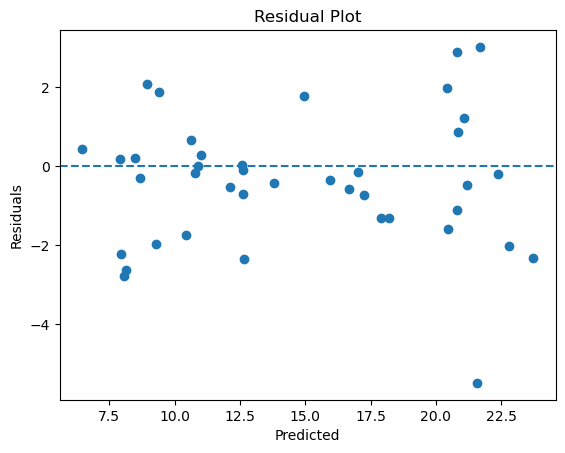

In [27]:
# Residual Analysis
residuals = y_test - y_pred

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Insights
The residual plot shows that residuals are randomly scattered around the zero line without any clear pattern. 
This indicates that the Multiple Linear Regression model adequately captures the relationship between advertising 
expenditure and sales. The absence of a systematic pattern suggests that the linearity assumption is reasonably satisfied.
Although a few observations exhibit larger residuals, the overall distribution supports the suitability of the model for
prediction.

### Business Insights
- TV advertising has the strongest impact on product sales.
- Radio advertising positively contributes to sales growth.
- Newspaper advertising does not significantly affect sales.
- The model explains more than 90% of sales variation, indicating strong predictive capability.
- Marketing budgets should prioritize TV and Radio advertising channels.
- Reducing Newspaper advertising expenditure may not significantly impact sales performance.

### Conclusion
This project used Multiple Linear Regression to evaluate the impact of TV, Radio, and Newspaper advertising on product
sales. Correlation analysis revealed that TV advertising had the strongest relationship with Sales, followed by Radio, 
while Newspaper showed a weak relationship. The model achieved an R² score of 0.906, indicating excellent predictive
performance. Statistical testing confirmed that TV and Radio advertising significantly influence sales, whereas Newspaper 
advertising was not statistically significant. Based on these findings, businesses should prioritize investment in TV and 
Radio advertising channels to maximize sales and marketing effectiveness.